In [65]:
!pip install vaderSentiment

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [67]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sentence = "There is no problem, all is fine"
analyzer = SentimentIntensityAnalyzer()
scores = analyzer.polarity_scores(sentence)

print(f"Scores: {scores}")
print(f"  - Negative: {scores['neg']:.2f}")
print(f"  - Neutral:  {scores['neu']:.2f}")
print(f"  - Positive: {scores['pos']:.2f}")
print(f"  - Compound: {scores['compound']:.2f}")

# Interpret the compound score
if scores['compound'] >= 0.5:
    sentiment = "POSITIVE"
elif scores['compound'] <= -0.5:
    sentiment = "NEGATIVE"
else:
    sentiment = "NEUTRAL"

print(f"  Overall Sentiment: {sentiment}")

# Display words that influenced the score
print("\n" + "="*60)
print("WORDS THAT INFLUENCED THE SENTIMENT SCORE:")
print("="*60)

# Access VADER's lexicon (dictionary of words with sentiment values)
lexicon = analyzer.lexicon

# Tokenize the sentence (simple split by spaces and punctuation)
import re
words = re.findall(r'\b\w+\b', sentence.lower())

# Find words that appear in VADER's lexicon
positive_words = []
negative_words = []
neutral_words = []

for word in words:
    if word in lexicon:
        score = lexicon[word]
        if score > 0:
            positive_words.append((word, score))
        elif score < 0:
            negative_words.append((word, score))
        else:
            neutral_words.append((word, score))

# Sort by absolute score value
positive_words.sort(key=lambda x: x[1], reverse=True)
negative_words.sort(key=lambda x: x[1])

print(f"\n🟢 POSITIVE WORDS ({len(positive_words)}):")
for word, score in positive_words:
    print(f"  '{word}': {score:+.2f}")

print(f"\n🔴 NEGATIVE WORDS ({len(negative_words)}):")
for word, score in negative_words:
    print(f"  '{word}': {score:+.2f}")

if neutral_words:
    print(f"\n⚪ NEUTRAL WORDS ({len(neutral_words)}):")
    for word, score in neutral_words:
        print(f"  '{word}': {score:+.2f}")

# Summary
print("\n" + "="*60)
print("SUMMARY:")
print("="*60)
print(f"Total sentiment words found: {len(positive_words) + len(negative_words) + len(neutral_words)}")
print(f"Positive words: {len(positive_words)}")
print(f"Negative words: {len(negative_words)}")
print(f"Net sentiment (positive - negative): {len(positive_words) - len(negative_words)}")



sentence = "There is no problem, all is fine"

Scores: {'neg': 0.0, 'neu': 0.552, 'pos': 0.448, 'compound': 0.4692}
  - Negative: 0.00
  - Neutral:  0.55
  - Positive: 0.45
  - Compound: 0.47
  Overall Sentiment: NEUTRAL

WORDS THAT INFLUENCED THE SENTIMENT SCORE:

🟢 POSITIVE WORDS (1):
  'fine': +0.80

🔴 NEGATIVE WORDS (2):
  'problem': -1.70
  'no': -1.20

SUMMARY:
Total sentiment words found: 3
Positive words: 1
Negative words: 2
Net sentiment (positive - negative): -1


In [68]:
df = pd.read_csv('/content/AirlineScrappedReview_Cleaned_seif_we_ibra#1.csv')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5),

In [70]:

df = df[df['Class'] != "Unknown"].reset_index(drop=True)
df = df[df['Traveller_Type'] != "Unknown"].reset_index(drop=True)
df = df[df['Traveller_Type'] != "Various"].reset_index(drop=True)
eqdf = df
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

df = pd.concat([df.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)

In [71]:
df = df.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Verified_Not Verified'], axis=1)

In [72]:
df

,Passanger_Name,Route,Rating,Review_title,Review_content,Start_Location,End_Location,Layover_Route,Start_Address,End_Address,Class_Business Class,Class_Economy Class,Class_First Class,Class_Premium Economy,Traveller_Type_Business,Traveller_Type_Couple Leisure,Traveller_Type_Family Leisure,Traveller_Type_Solo Leisure,Verified_Trip Verified
0,Paige Boet,New Orleans to London,1.0,The airline lost my luggage,The airline lost my luggage and was absolutely...,New Orleans,London,NaN,"New Orleans, Orleans Parish, Louisiana, United...","London, Greater London, England, United Kingdom",0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,S Layne,London to Amman,1.0,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",London,Amman,NaN,"London, Greater London, England, United Kingdom","عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...",1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,E Lanewoski,Heathrow to Bodrum,2.0,no boarding drinks provided,"First time flying with BA business class, neve...",London Heathrow,Bodrum,NaN,"London Heathrow Airport, The Beacon Roundabout...","Bodrum, Muğla, Ege Bölgesi, Türkiye",1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,Joel Burman,Amman to London,4.0,WiFi didn't work,You can buy sandwiches and crisps but don't ex...,Amman,London,NaN,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,...","London, Greater London, England, United Kingdom",0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,R Vines,London City to Ibiza,7.0,stick with economy,This is a two-for-one review covering economy ...,London City,Ibiza,NaN,"London City Airport, Connaught Road, Silvertow...","Eivissa, Illes Balears, España",1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,Sasha Guignard,Kiev to London,8.0,British Airways customer review,Flew from Kiev to London on their Airbus 319 i...,Kiev,London,NaN,"Київ, Україна","London, Greater London, England, United Kingdom",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2799,D Ross,London-Vancouver,7.0,British Airways customer review,LHR to YVR return. Hard earned Avios points tr...,London,Vancouver,NaN,"London, Greater London, England, United Kingdom","Vancouver, Metro Vancouver Regional District, ...",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2800,J Brown,LHR-ORD,5.0,British Airways customer review,Club World from LHR-ORD. Busy flight on the ag...,London Heathrow,"Chicago (IL), O'Hare International Airport",NaN,"London Heathrow Airport, The Beacon Roundabout...","O'Hare International Airport, 10000, West Higg...",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2801,Kevin Barrance,BOM-LHR,3.0,British Airways customer review,This review refers to a return trip from India...,Bombay (Mumbai) - Chhatrapati Shivaji Internat...,London Heathrow,NaN,Chhatrapati Shivaji Maharaj International Airp...,"London Heathrow Airport, Northern Perimeter Ro...",0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [73]:
# Add the "Satisfied" column
df['Satisfied'] = (df['Rating'] >= 5).astype(int)

# Verify the new column
print("Satisfied column added!")
print("\nValue counts:")
print(df['Satisfied'].value_counts())

print("\nBreakdown by Rating:")
print(df.groupby('Rating')['Satisfied'].value_counts().unstack(fill_value=0))

print("\nSample rows:")
print(df[['Passanger_Name', 'Rating', 'Satisfied']].head(10))

# Check the dataframe info
print("\nUpdated DataFrame info:")
df.info()

Satisfied column added!

Value counts:
Satisfied
0    1586
1    1217
Name: count, dtype: int64

Breakdown by Rating:
Satisfied    0    1
Rating             
1.0        707    0
2.0        341    0
3.0        343    0
4.0        195    0
5.0          0  174
6.0          0  135
7.0          0  221
8.0          0  267
9.0          0  207
10.0         0  213

Sample rows:
   Passanger_Name  Rating  Satisfied
0      Paige Boet     1.0          0
1         S Layne     1.0          0
2     E Lanewoski     2.0          0
3     Joel Burman     4.0          0
4         R Vines     7.0          1
5          M King     1.0          0
6          C Dean     1.0          0
7  Richard Hodges     7.0          1
8  Carol Willmore     1.0          0
9   Nadine Kohler     1.0          0

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                   

In [74]:
df['Layover_Route'] = df['Layover_Route'].fillna('None')

In [75]:
df['Route'].value_counts()

,count
Route,
London to Johannesburg,16
London to Cape Town,15
Vancouver to London,13
BKK to LHR,13
Johannesburg to London,13
...,...
BOM-LHR,1
LHR to Santorini,1
Seattle to Nice via London,1


In [76]:
df['Route'] = df['Route'].str.replace('Johannesburg', 'JNB')
df['Route'] = df['Route'].str.replace('Cape Town', 'CPT')
df['Route'] = df['Route'].str.replace('London Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace('London Gatwick', 'LGW')
df['Route'] = df['Route'].str.replace('Hong Kong', 'HKG')
df['Route'] = df['Route'].str.replace(' to San Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace('San Francisco to ', ' SFO to')
df['Route'] = df['Route'].str.replace('Rotterdam', 'RTM')
df['Route'] = df['Route'].str.replace('Muscat', 'MCT')
df['Route'] = df['Route'].str.replace('Lisbon', 'LIS')
df['Route'] = df['Route'].str.replace('Pisa London Heathrow', 'PSA via LHR')
df['Route'] = df['Route'].str.replace('London Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace('JNB / Heathrow', 'JNB / LHR')
df['Route'] = df['Route'].str.replace('London UK (Heathrow)', 'LHR')
df['Route'] = df['Route'].str.replace('London-Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace('London Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace(' via Heathrow', ' via LHR')
df['Route'] = df['Route'].str.replace('Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace('Heathrow', 'LHR')
df['Route'] = df['Route'].str.replace(' toIbiza', ' to IBZ')
df['Route'] = df['Route'].str.replace('Ibiza', 'IBZ')
df['Route'] = df['Route'].str.replace(' toBodrum', ' to BJV')
df['Route'] = df['Route'].str.replace('Bodrum', 'BJV')
df['Route'] = df['Route'].str.replace('Aberdeen', 'ABZ')
df['Route'] = df['Route'].str.replace('Tampa', 'TPA')
df['Route'] = df['Route'].str.replace('Gatwick', 'LGW')
df['Route'] = df['Route'].str.replace('toDubai', 'to DXC')
df['Route'] = df['Route'].str.replace('toBarcelona', 'to BCN')
df['Route'] = df['Route'].str.replace('Islamabad', 'ISB')
df['Route'] = df['Route'].str.replace('Dallas Fort-Worth to ', 'DFW to ')
df['Route'] = df['Route'].str.replace('Dallas Ft Worth to ', 'DFW to ')
df['Route'] = df['Route'].str.replace('Dallas', 'DFW')
df['Route'] = df['Route'].str.replace('Geneva', 'GVA')
df['Route'] = df['Route'].str.replace('Barbados', 'BGI')
df['Route'] = df['Route'].str.replace('Bridgetown', 'BGI')
df['Route'] = df['Route'].str.replace(' to Genoa', ' to GOA')
df['Route'] = df['Route'].str.replace(' to Nice', ' to NCE')
df['Route'] = df['Route'].str.replace('Nice to DFW via London', 'NCE to DFW via London')
df['Route'] = df['Route'].str.replace('Nice to Kuwait via London', 'NCE to KWI via London')
df['Route'] = df['Route'].str.replace('Nice to LGW', 'NCE to LGW')
df['Route'] = df['Route'].str.replace('Nice to LHR', 'NCE to LHR')
df['Route'] = df['Route'].str.replace('Oakland to ', 'OAK to ')
df['Route'] = df['Route'].str.replace('Kuwait', 'KWI')
df['Route'] = df['Route'].str.replace(' to Geneva', ' to GVA')
df['Route'] = df['Route'].str.replace('Barbados to ', 'BGI to ')
df['Route'] = df['Route'].str.replace(' to Male', ' to MLE')
df['Route'] = df['Route'].str.replace('Male to ', 'MLE to ')
df['Route'] = df['Route'].str.replace(' toMalaga', ' to AGP')
df['Route'] = df['Route'].str.replace('Malaga', 'AGP')
df['Route'] = df['Route'].str.replace('Newcastle', 'NCL')
df['Route'] = df['Route'].str.replace('-Florence', ' to FLR')
df['Route'] = df['Route'].str.replace('Florence', 'FLR')
df['Route'] = df['Route'].str.replace('Brindisi', 'BDS')
df['Route'] = df['Route'].str.replace('Gibraltar', 'GIB')
df['Route'] = df['Route'].str.replace('Bangalore', 'BLR')
df['Route'] = df['Route'].str.replace(' toAmsterdam', ' to AMS')
df['Route'] = df['Route'].str.replace('Amsterdam', 'AMS')
df['Route'] = df['Route'].str.replace('Prague', 'PRG')
df['Route'] = df['Route'].str.replace('Zagreb', 'ZAG')
df['Route'] = df['Route'].str.replace('Tehran', 'THR')
df['Route'] = df['Route'].str.replace('Seville', 'SVQ')
df['Route'] = df['Route'].str.replace('Belfast  to ', 'BFS to ')
df['Route'] = df['Route'].str.replace('Belfast City to ', 'BFS to ')
df['Route'] = df['Route'].str.replace(' toBelfast', ' to BFS')
df['Route'] = df['Route'].str.replace('Belfast', 'BFS')
df['Route'] = df['Route'].str.replace('toJFK (New York City)', 'to JFK')
df['Route'] = df['Route'].str.replace('toEdinburgh', 'to EDI')
df['Route'] = df['Route'].str.replace('Edinburgh', 'EDI')
df['Route'] = df['Route'].str.replace('Riyadh', 'RUH')
df['Route'] = df['Route'].str.replace(' toSantorini', ' to JTR')
df['Route'] = df['Route'].str.replace('Santorini', 'JTR')
df['Route'] = df['Route'].str.replace(' to Murcia', ' to RMU')
df['Route'] = df['Route'].str.replace('Manchester, UK to ', 'MAN to ')
df['Route'] = df['Route'].str.replace(' toManchester', ' to MAN')
df['Route'] = df['Route'].str.replace('Manchester', 'MAN')
df['Route'] = df['Route'].str.replace('Helsinki to ', 'HEL to ')
df['Route'] = df['Route'].str.replace(' to Helsinki', ' to HEL')
df['Route'] = df['Route'].str.replace('Tokyo Narita to ', 'NRT to ')
df['Route'] = df['Route'].str.replace(' to Tokyo Narita', ' to NRT')
df['Route'] = df['Route'].str.replace('San Francisco to ', 'SFO to ')
df['Route'] = df['Route'].str.replace(' to San Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to San francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to san Francisco', ' to SFO')
df['Route'] = df['Route'].str.replace(' to San Fran', ' to SFO')
df['Route'] = df['Route'].str.replace('SFOsisco', 'SFO')
df['Route'] = df['Route'].str.replace('Nairobi', 'NBO')
df['Route'] = df['Route'].str.replace('Jeddah', 'JED')
df['Route'] = df['Route'].str.replace(' toHouston', ' to IAH')
df['Route'] = df['Route'].str.replace('Houston', 'IAH')
df['Route'] = df['Route'].str.replace(' toLyon', ' to LYS')
df['Route'] = df['Route'].str.replace('Lyon', 'LYS')
df['Route'] = df['Route'].str.replace('Seoul', 'ICN')
df['Route'] = df['Route'].str.replace(' toVienna', ' to VIE')
df['Route'] = df['Route'].str.replace('Vienna', 'VIE')
df['Route'] = df['Route'].str.replace('Bermuda', 'BDA')
df['Route'] = df['Route'].str.replace(' toMarseille', ' to MRS')
df['Route'] = df['Route'].str.replace('Marseille', 'MRS')
df['Route'] = df['Route'].str.replace('London to CPT', 'LHR to CPT')
df['Route'] = df['Route'].str.replace('London to JNB', 'LHR to JNB')
df['Route'] = df['Route'].str.replace('Los Angeles to London', 'LAX to LHR')
df['Route'] = df['Route'].str.replace('JNB to London', 'JNB to LHR')
df['Route'] = df['Route'].str.replace('London to Athens', 'LHR to ATH')
df['Route'] = df['Route'].str.replace('London to Athens Greece', 'LHR to ATH')
df['Route'] = df['Route'].str.replace('Athens', 'ATH')
df['Route'] = df['Route'].str.replace('HKG toLondon', 'HKG to LHR')
df['Route'] = df['Route'].str.replace('SFO toLondon', 'SFO to LHR')
df['Route'] = df['Route'].str.replace('Vancouver to London', 'YVR to LHR')
df['Route'] = df['Route'].str.replace('Vancouver to ', 'YVR to ')
df['Route'] = df['Route'].str.replace(' to Vancouver', ' to YVR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('CPT to London', 'CPT to LHR')
df['Route'] = df['Route'].str.replace('London to Toronto', 'LHR to YYZ')
df['Route'] = df['Route'].str.replace('Toronto', 'YYZ')
df['Route'] = df['Route'].str.replace('Singapore to London', 'SIN to LHR')
df['Route'] = df['Route'].str.replace('London to HKG', 'LHR to HKG')
df['Route'] = df['Route'].str.replace(' toFaro', ' to FAO')
df['Route'] = df['Route'].str.replace(' toZurich', ' to ZRH')
df['Route'] = df['Route'].str.replace(' toBahrain', ' to BAH')
df['Route'] = df['Route'].str.replace('toNew York', 'to JFK')
df['Route'] = df['Route'].str.replace(' toJNB', ' to JNB')
df['Route'] = df['Route'].str.replace(' toBrussels', ' to CRL')
df['Route'] = df['Route'].str.replace('Faro', 'FAO')
df['Route'] = df['Route'].str.replace('Shannon', 'SNN')
df['Route'] = df['Route'].str.replace('Hamburg', 'HAM')
df['Route'] = df['Route'].str.replace('Calgary', 'CYY')
df['Route'] = df['Route'].str.replace('Zurich', 'ZRH')
df['Route'] = df['Route'].str.replace('Dublin', 'DUB')
df['Route'] = df['Route'].str.replace('Durban', 'DUR')
df['Route'] = df['Route'].str.replace('Larnaca', 'LCA')
df['Route'] = df['Route'].str.replace('Dubai', 'DXB')
df['Route'] = df['Route'].str.replace('Bahrain', 'BAH')
df['Route'] = df['Route'].str.replace('Tirana Rinas', 'TIA')
df['Route'] = df['Route'].str.replace('New York JFK', 'JFK')
df['Route'] = df['Route'].str.replace('New York', 'JFK')
df['Route'] = df['Route'].str.replace(' toLas Vegas', ' to LAS')
df['Route'] = df['Route'].str.replace('Las Vegas', 'LAS')
df['Route'] = df['Route'].str.replace('Phoenix', 'PHX')
df['Route'] = df['Route'].str.replace('Los Angeles', 'LAX')
df['Route'] = df['Route'].str.replace('Singapore', 'SIN')
df['Route'] = df['Route'].str.replace('Boston', 'BOS')
df['Route'] = df['Route'].str.replace('Funchal', 'FNC')
df['Route'] = df['Route'].str.replace('toMadeira', 'to FNC')
df['Route'] = df['Route'].str.replace('Madeira', 'FNC')
df['Route'] = df['Route'].str.replace('London to ', 'LHR to ')
df['Route'] = df['Route'].str.replace(' to London', ' to LHR')
df['Route'] = df['Route'].str.replace(' toLondon', ' to LHR')
df['Route'] = df['Route'].str.replace('Kuala Lumpur to ', 'KUL to ')
df['Route'] = df['Route'].str.replace(' to Kuala Lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace(' toKuala Lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace(' to Kuala lumpur', ' to KUL')
df['Route'] = df['Route'].str.replace('Brussels', 'CRL')
df['Route'] = df['Route'].str.replace('Istanbul', 'IST')
df['Route'] = df['Route'].str.replace('Arlanda Stockholm', 'ARN')
df['Route'] = df['Route'].str.replace('Stockholm', 'ARN')
df['Route'] = df['Route'].str.replace('Stockholm Arlanda', 'ARN')
df['Route'] = df['Route'].str.replace(' to Stockholm Arlanda', ' to ARN')
df['Route'] = df['Route'].str.replace(' toBangkok', ' to BKK')
df['Route'] = df['Route'].str.replace('Bangkok', 'BKK')
df['Route'] = df['Route'].str.replace('Madrid', 'MAD')
df['Route'] = df['Route'].str.replace('Berlin Tegel', 'TXL')
df['Route'] = df['Route'].str.replace('Berlin', 'TXL')
df['Route'] = df['Route'].str.replace('Sydney to ', 'SYD to ')
df['Route'] = df['Route'].str.replace(' to Sydney', ' to SYD')
df['Route'] = df['Route'].str.replace('Cancun to ', 'CUN to ')
df['Route'] = df['Route'].str.replace(' to Cancun', ' to CUN')
df['Route'] = df['Route'].str.replace(' toCancun', ' to CUN')
df['Route'] = df['Route'].str.replace("Chicago O'Hare", 'ORD')
df['Route'] = df['Route'].str.replace('Chicago', 'ORD')
df['Route'] = df['Route'].str.replace('New York to ', 'JFK to ')
df['Route'] = df['Route'].str.replace(' to New York', ' to JFK')
df['Route'] = df['Route'].str.replace('New York to ', 'JFK to ')
df['Route'] = df['Route'].str.replace(' to New York', ' to JFK')
df['Route'] = df['Route'].str.replace('Mauritius to ', 'MRU to ')
df['Route'] = df['Route'].str.replace(' to Mauritius', ' to MRU')
df['Route'] = df['Route'].str.replace('Algiers to ', 'ALG to ')
df['Route'] = df['Route'].str.replace(' to Algiers', ' to ALG')
df['Route'] = df['Route'].str.replace('Punta Cana to ', 'PUJ to ')
df['Route'] = df['Route'].str.replace(' to Punta Cana', ' to PUJ')
df['Route'] = df['Route'].str.replace('Marrakech to ', 'RAK to ')
df['Route'] = df['Route'].str.replace(' to Marrakech', ' to RAK')
df['Route'] = df['Route'].str.replace('Lanzarote to ', 'ACE to ')
df['Route'] = df['Route'].str.replace(' to Lanzarote', ' to ACE')
df['Route'] = df['Route'].str.replace('Krakow', 'KRK')
df['Route'] = df['Route'].str.replace('Kraków', 'KRK')
df['Route'] = df['Route'].str.replace('Kefalonia', 'EFL')
df['Route'] = df['Route'].str.replace('doha to londonDOH to LHR', 'DOH to LHR')
df['Route'] = df['Route'].str.replace('Tel Aviv', 'TLV')
df['Route'] = df['Route'].str.replace('Seattle to ', 'SEA to ')
df['Route'] = df['Route'].str.replace(' to Seattle', ' to SEA')
df['Route'] = df['Route'].str.replace('Washington', 'SEA')
df['Route'] = df['Route'].str.replace('Washington DC', 'IAD')
df['Route'] = df['Route'].str.replace('Washington Dulles', 'IAD')
df['Route'] = df['Route'].str.replace('Copenhagen to ', 'CPH to ')
df['Route'] = df['Route'].str.replace(' to Copenhagen', ' to CPH')
df['Route'] = df['Route'].str.replace(' toCopenhagen', ' to CPH')
df['Route'] = df['Route'].str.replace(' to Denver', ' to DEN')
df['Route'] = df['Route'].str.replace('Denver to ', 'DEN to ')
df['Route'] = df['Route'].str.replace(' to Barcelona', ' to BCN')
df['Route'] = df['Route'].str.replace('Barcelona to ', 'BCN to ')
df['Route'] = df['Route'].str.replace(' to Gothenburg', ' to GOT')
df['Route'] = df['Route'].str.replace('Gothenburg to ', 'GOT to ')
df['Route'] = df['Route'].str.replace(' to Jersey', ' to JER')
df['Route'] = df['Route'].str.replace('Jersey to ', 'JER to ')
df['Route'] = df['Route'].str.replace(' to Lebanon', ' to BEY')
df['Route'] = df['Route'].str.replace('Lebanon to ', 'BEY to ')
df['Route'] = df['Route'].str.replace(' to Mallorca', ' to PMI')
df['Route'] = df['Route'].str.replace('Mallorca to ', 'PMI to ')
df['Route'] = df['Route'].str.replace(' to Venice Marco Polo', ' to VCE')
df['Route'] = df['Route'].str.replace('Venice Marco Polo to ', 'VCE to ')
df['Route'] = df['Route'].str.replace(' to Venice', ' to VCE')
df['Route'] = df['Route'].str.replace('Venice to ', 'VCE to ')
df['Route'] = df['Route'].str.replace(' to  Gatwick', ' to LGW')
df['Route'] = df['Route'].str.replace('Doha', 'DOH')
df['Route'] = df['Route'].str.replace('Paris CDG', 'CDG')
df['Route'] = df['Route'].str.replace('Paris CDG to ', 'CDG to ')
df['Route'] = df['Route'].str.replace('to Paris Orly', 'to ORY')
df['Route'] = df['Route'].str.replace('Paris', 'CDG')
df['Route'] = df['Route'].str.replace(' toMiami', ' to MIA')
df['Route'] = df['Route'].str.replace('Sofia', 'SOF')
df['Route'] = df['Route'].str.replace('Delhi to ', 'DEL to ')
df['Route'] = df['Route'].str.replace(' to Delhi', ' to DEL')
df['Route'] = df['Route'].str.replace(' to Delhi Airport', ' to DEL')
df['Route'] = df['Route'].str.replace(' to New Delhi', ' to DEL')
df['Route'] = df['Route'].str.replace(' to Frankfurt', ' to FRA')
df['Route'] = df['Route'].str.replace('Frankfurt to ', 'FRA to ')
df['Route'] = df['Route'].str.replace(' toGlasgow', ' to GLA')
df['Route'] = df['Route'].str.replace('Glasgow', 'GLA')
df['Route'] = df['Route'].str.replace('Antigua', 'ANU')
df['Route'] = df['Route'].str.replace('St Lucia', 'UVF')
df['Route'] = df['Route'].str.replace('Rome FCO ', 'FCO')
df['Route'] = df['Route'].str.replace('Rome Fiumicino', 'FCO')
df['Route'] = df['Route'].str.replace('Rome', 'FCO')
df['Route'] = df['Route'].str.replace(' to Cairo', ' to CAI')
df['Route'] = df['Route'].str.replace('Cairo to ', 'CAI to ')
df['Route'] = df['Route'].str.replace(' to Bucharest', ' to OTP')
df['Route'] = df['Route'].str.replace('Bucharest to ', 'OTP to ')
df['Route'] = df['Route'].str.replace('London-Vancouver', 'LHR to YVR')
df['Route'] = df['Route'].str.replace('Vancouver Canada', 'YVR')
df['Route'] = df['Route'].str.replace('toVancouver', 'to YVR')
df['Route'] = df['Route'].str.replace(' to Grand Cayman', ' to GCM')
df['Route'] = df['Route'].str.replace('Grand Cayman to ', 'GCM to ')
df['Route'] = df['Route'].str.replace('Cayman Islands', 'GCM')
df['Route'] = df['Route'].str.replace('Nassau', 'NAS')
df['Route'] = df['Route'].str.replace('Orlando', 'MCO')
df['Route'] = df['Route'].str.replace('Tirana', 'TIA')
df['Route'] = df['Route'].str.replace('Mahe', 'SEZ')
df['Route'] = df['Route'].str.replace('Seychelles', 'SEZ')
df['Route'] = df['Route'].str.replace('Sydney', 'SYD')
df['Route'] = df['Route'].str.replace('toSYD', 'to SYD')
df['Route'] = df['Route'].str.replace('toMunich', 'to MUC')
df['Route'] = df['Route'].str.replace('Munich', 'to MUC')
df['Route'] = df['Route'].str.replace('Santiago', 'to SCL')
df['Route'] = df['Route'].str.replace('Porto', 'to OPO')
df['Route'] = df['Route'].str.replace('Naples', 'to NAP')
df['Route'] = df['Route'].str.replace('London LGW', 'LGW')
df['Route'] = df['Route'].str.replace('London City', 'LHR')
df['Route'] = df['Route'].str.replace('to Bergerac', 'to EGC')
df['Route'] = df['Route'].str.replace('Antigua', 'ANU')
df['Route'] = df['Route'].str.replace('via London', 'via LHR')
df['Route'] = df['Route'].str.replace('TIA London', 'TIA via LHR')
df['Route'] = df['Route'].str.replace('to London', 'to LHR')
df['Route'] = df['Route'].str.replace('RUH to  London', 'RUH to LHR')
df['Route'] = df['Route'].str.replace('Port of Spain', 'POS')
df['Route'] = df['Route'].str.replace('Pisa', 'PSA')
df['Route'] = df['Route'].str.replace('Abuja Nigeria', 'ABV')
df['Route'] = df['Route'].str.replace('Abuja, Nigeria', 'ABV')
df['Route'] = df['Route'].str.replace('TPA International', 'TPA')
df['Route'] = df['Route'].str.replace('Los Angesles', 'LAX')
df['Route'] = df['Route'].str.replace('St Petersburgh', 'LED')
df['Route'] = df['Route'].str.replace('St Petersburg', 'LED')
df['Route'] = df['Route'].str.replace('to LED', 'to LED')
df['Route'] = df['Route'].str.replace('Singapire', 'SIN')
df['Route'] = df['Route'].str.replace('Istambul', 'IST')
df['Route'] = df['Route'].str.replace('Turkey', 'IST')
df['Route'] = df['Route'].str.replace('MCO MCO', 'MCO')
df['Route'] = df['Route'].str.replace('Kingston', 'KIN')
df['Route'] = df['Route'].str.replace(' toAberdeen', ' to ABZ')
df['Route'] = df['Route'].str.replace('Leeds Bradford', 'LBA')
df['Route'] = df['Route'].str.replace('Leeds', 'LBA')
df['Route'] = df['Route'].str.replace('Baltimore', 'BWI')
df['Route'] = df['Route'].str.replace('Lagos', 'LOS')
df['Route'] = df['Route'].str.replace('São Paulo', 'GRU')
df['Route'] = df['Route'].str.replace('Sao Paulo', 'GRU')
df['Route'] = df['Route'].str.replace('Palma de PMI', 'PMI')
df['Route'] = df['Route'].str.replace('toWarsaw', 'to WAW')
df['Route'] = df['Route'].str.replace('Warsaw', 'WAW')
df['Route'] = df['Route'].str.replace('Hyderabad', 'to HYD')
df['Route'] = df['Route'].str.replace('Singapore', 'SIN')
df['Route'] = df['Route'].str.replace('Buenos Aires', 'EZE')
df['Route'] = df['Route'].str.replace('Budapest', 'BUD')
df['Route'] = df['Route'].str.replace('Bologna', 'BLQ')
df['Route'] = df['Route'].str.replace('Luxembourg', 'LUX')
df['Route'] = df['Route'].str.replace('Dusseldorf', 'DUS')
df['Route'] = df['Route'].str.replace('Düsseldorf', 'DUS')
df['Route'] = df['Route'].str.replace('Duesseldorf', 'DUS')
df['Route'] = df['Route'].str.replace('Fuereventura', 'FUE')
df['Route'] = df['Route'].str.replace('Fort Lauderdale', 'FLL')
df['Route'] = df['Route'].str.replace('toSan Jose', 'SJC')
df['Route'] = df['Route'].str.replace('San Jose Costa Rica', 'SJO')
df['Route'] = df['Route'].str.replace('San Jose, CA', 'SJC')
df['Route'] = df['Route'].str.replace('San Jose', 'SJC')
df['Route'] = df['Route'].str.replace('Hannover', 'HAJ')
df['Route'] = df['Route'].str.replace('Billund', 'BLL')
df['Route'] = df['Route'].str.replace('Philadelphia', 'PHL')
df['Route'] = df['Route'].str.replace('Newark', 'EWR')
df['Route'] = df['Route'].str.replace('Salzburg', 'SZG')
df['Route'] = df['Route'].str.replace('alicante', 'ALC')
df['Route'] = df['Route'].str.replace('Alicante', 'ALC')
df['Route'] = df['Route'].str.replace('toMexico City', 'to MEX')
df['Route'] = df['Route'].str.replace('Mexico City', 'MEX')
df['Route'] = df['Route'].str.replace('Geneva', 'GVA')
df['Route'] = df['Route'].str.replace('Cologne', 'CGN')
df['Route'] = df['Route'].str.replace('toMilan', 'to MXP')
df['Route'] = df['Route'].str.replace('Milan', 'MXP')
df['Route'] = df['Route'].str.replace('Mahon', 'MAH')
df['Route'] = df['Route'].str.replace('Thessaloniki', 'SKG')
df['Route'] = df['Route'].str.replace('LHR Cuty', 'LCY')
df['Route'] = df['Route'].str.replace('Inverness', 'IAD')
df['Route'] = df['Route'].str.replace('Entebbe', 'EBB')
df['Route'] = df['Route'].str.replace('return', '')
df['Route'] = df['Route'].str.replace('Airport', '')
df['Route'] = df['Route'].str.replace('toCPT', 'to CPT')
df['Route'] = df['Route'].str.replace('toMumbai', 'to BOM')
df['Route'] = df['Route'].str.replace('Mumbai', 'BOM')
df['Route'] = df['Route'].str.replace('Luanda', 'LAD')
df['Route'] = df['Route'].str.replace('Verona', 'VRN')
df['Route'] = df['Route'].str.replace('MXP Malpensa', 'MXP')
df['Route'] = df['Route'].str.replace('Shanghai', 'PVG')
df['Route'] = df['Route'].str.replace('Cephalonia', 'EFL')
df['Route'] = df['Route'].str.replace('Bengaluru', 'BLR')
df['Route'] = df['Route'].str.replace('Beijing', 'PEK')
df['Route'] = df['Route'].str.replace('Moscow', 'SVO')
df['Route'] = df['Route'].str.replace('Chennai', 'MAA')
df['Route'] = df['Route'].str.replace('Austin', 'AUS')
df['Route'] = df['Route'].str.replace('Keflavik', 'KEF')
df['Route'] = df['Route'].str.replace('Toulouse', 'TLS')
df['Route'] = df['Route'].str.replace('Accra', 'ACC')
df['Route'] = df['Route'].str.replace('Reykjavik', 'RKV')
df['Route'] = df['Route'].str.replace('LHR City', 'LHR')
df['Route'] = df['Route'].str.replace('Abu Dhabi', 'AUH')
df['Route'] = df['Route'].str.replace('Chengdu', 'CTU')
df['Route'] = df['Route'].str.replace('toSVO', 'to SVO')
df['Route'] = df['Route'].str.replace('St Kitts', 'SKB')
df['Route'] = df['Route'].str.replace('lgw', 'LGW')
df['Route'] = df['Route'].str.replace('Madrid', 'MAD')
df['Route'] = df['Route'].str.replace('toHaneda', 'to HND')
df['Route'] = df['Route'].str.replace('Granada', 'GRX')
df['Route'] = df['Route'].str.replace('Montreal', 'YUL')
df['Route'] = df['Route'].str.replace('Montréal', 'YUL')
df['Route'] = df['Route'].str.replace('Portland', 'PDX')
df['Route'] = df['Route'].str.replace('London SIN', 'LHR to SIN')
df['Route'] = df['Route'].str.replace('Palma to LGW', 'PMI to LGW')
df['Route'] = df['Route'].str.replace('toLHR', 'to LHR')
df['Route'] = df['Route'].str.replace('BLL, Denmark', 'BLL')
df['Route'] = df['Route'].str.replace('Gatwick', 'LGW')
df['Route'] = df['Route'].str.replace('toInnsbruck', 'to Innsbruck')
df['Route'] = df['Route'].str.replace('Bergen', 'BGO')
df['Route'] = df['Route'].str.replace('Edmonton', 'YEG')
df['Route'] = df['Route'].str.replace('Catania', 'CTA')
df['Route'] = df['Route'].str.replace('Bordeaux', 'BOD')
df['Route'] = df['Route'].str.replace('Miami', 'MIA')
df['Route'] = df['Route'].str.replace('MIa', 'MIA')
df['Route'] = df['Route'].str.replace('Rio de Janiero', 'GIG')
df['Route'] = df['Route'].str.replace('Rio de Janeiro', 'GIG')
df['Route'] = df['Route'].str.replace('Rio De Janeiro', 'GIG')
df['Route'] = df['Route'].str.replace('toBLQ', 'BLQ')
df['Route'] = df['Route'].str.replace('Victoria Falls', 'VFA')
df['Route'] = df['Route'].str.replace('Seoul Incheon', 'ICN')
df['Route'] = df['Route'].str.replace('New Orleans', 'MSY')
df['Route'] = df['Route'].str.replace('Oslo', 'OSL')
df['Route'] = df['Route'].str.replace('oslo', 'OSL')
df['Route'] = df['Route'].str.replace('toBilbao', 'to BIO')
df['Route'] = df['Route'].str.replace('Kalamata', 'KLX')
df['Route'] = df['Route'].str.replace('iAH', 'IAH')
df['Route'] = df['Route'].str.replace('Mexico', 'MEX')
df['Route'] = df['Route'].str.replace('LHR,', 'LHR')
df['Route'] = df['Route'].str.replace('ATH  Greece,', 'ATH')
df['Route'] = df['Route'].str.replace('toBGO', 'to BGO')
df['Route'] = df['Route'].str.replace('toBGO', 'to BGO')
df['Route'] = df['Route'].str.replace('Bilbao', '')
df['Route'] = df['Route'].str.replace('toBGO', 'to BGO')
df['Route'] = df['Route'].str.replace('Bilbao', 'BIO')
df['Route'] = df['Route'].str.replace('toTenerife', 'to TFS')
df['Route'] = df['Route'].str.replace('Tenerife South', 'TFS')
df['Route'] = df['Route'].str.replace('Tenerife south', 'TFS')
df['Route'] = df['Route'].str.replace('Tenerife', 'TFS')
df['Route'] = df['Route'].str.replace('Kos', 'KGS')
df['Route'] = df['Route'].str.replace('Kyiv', 'KBP')
df['Route'] = df['Route'].str.replace('Kiev', 'KBP')
df['Route'] = df['Route'].str.replace('Tokyo Haneda', 'HND')
df['Route'] = df['Route'].str.replace('Tokyo', 'HND')
df['Route'] = df['Route'].str.replace('Amman Jordan', 'AMM')
df['Route'] = df['Route'].str.replace('Amman', 'AMM')
df['Route'] = df['Route'].str.replace('Dubrovnik', 'DBV')
df['Route'] = df['Route'].str.replace('Marrakesh', 'RAK')
df['Route'] = df['Route'].str.replace('Marrakech', 'RAK')
df['Route'] = df['Route'].str.replace('Grenada', 'GND')
df['Route'] = df['Route'].str.replace('Bari', 'BRI')
df['Route'] = df['Route'].str.replace('Lima', 'LIM')
df['Route'] = df['Route'].str.replace('TXL Tegel', 'TXL')
df['Route'] = df['Route'].str.replace('Lima', 'LIM')
df['Route'] = df['Route'].str.replace('San Diego', 'SAN')
df['Route'] = df['Route'].str.replace('Ottawa', 'YOW')
df['Route'] = df['Route'].str.replace('Ahmedabad', 'AMD')
df['Route'] = df['Route'].str.replace('Malta', 'MLA')
df['Route'] = df['Route'].str.replace('Nashville', 'BNA')
df['Route'] = df['Route'].str.replace('Heraklion', 'HER')
df['Route'] = df['Route'].str.replace('Atlanta', 'ATL')
df['Route'] = df['Route'].str.replace('Copenhagen', 'CPH')
df['Route'] = df['Route'].str.replace('Cyprus', 'LCA')
df['Route'] = df['Route'].str.replace('Melbourne', 'MEL')
df['Route'] = df['Route'].str.replace('Sweden', 'OSL')
df['Route'] = df['Route'].str.replace('Paphos', 'PFO')
df['Route'] = df['Route'].str.replace('Los Angeles', 'LAX')
df['Route'] = df['Route'].str.replace('SEA Tacoma', 'SEA')
df['Route'] = df['Route'].str.replace('Corfu', 'CFU')
df['Route'] = df['Route'].str.replace('Manila', 'MNL')
df['Route'] = df['Route'].str.replace('ICN Incheon', 'ICN')
df['Route'] = df['Route'].str.replace('Auckland', 'AKL')
df['Route'] = df['Route'].str.replace('Turin', 'TRN')
df['Route'] = df['Route'].str.replace('Bristol', 'BRS')
df['Route'] = df['Route'].str.replace('Tobago', 'TAB')
df['Route'] = df['Route'].str.replace('Auckland', 'AKL')
df['Route'] = df['Route'].str.replace('Saint Lucia', '')
df['Route'] = df['Route'].str.replace('LHR Heaathrow', 'LHR')
df['Route'] = df['Route'].str.replace('Bombay', 'BOM')
df['Route'] = df['Route'].str.replace('Edimbourgh', 'EDI')
df['Route'] = df['Route'].str.replace('Seattle', 'SEA')
df['Route'] = df['Route'].str.replace('Mykonos', 'JMK')
df['Route'] = df['Route'].str.replace('Abuja', 'ABV')
df['Route'] = df['Route'].str.replace('MCO, Florida', 'MCO')
df['Route'] = df['Route'].str.replace('ACC, Ghana', 'ACC')
df['Route'] = df['Route'].str.replace('Maldives', 'MLE')
df['Route'] = df['Route'].str.replace('SEA Dulles', 'IAD')
df['Route'] = df['Route'].str.replace('Lahore', 'LHE')
df['Route'] = df['Route'].str.replace('Domodedovo', 'DME')
df['Route'] = df['Route'].str.replace('OR Tambo', 'JNB')
df['Route'] = df['Route'].str.replace('Antalya', 'AYT')
df['Route'] = df['Route'].str.replace('Stuttgart', 'STR')
df['Route'] = df['Route'].str.replace('Tallinn', 'TLL')
df['Route'] = df['Route'].str.replace('Heathrow (London) to JFK (JFK City)', 'LHR to JFK')

In [77]:
with pd.option_context('display.max_rows', None):
    display(df['Route'].value_counts())

,count
Route,
LHR to JFK,32
LHR to JNB,30
JFK to LHR,27
LHR to DXB,27
LHR to CPT,26
LHR to BKK,25
LHR to HKG,24
YVR to LHR,23
LHR to MIA,23


# **Distribution of top 10 routes bookings across flight hours**

In [78]:
eqdf2 = pd.read_csv('/content/Passanger_booking_data.csv')
eqdf2 = eqdf2.drop_duplicates()

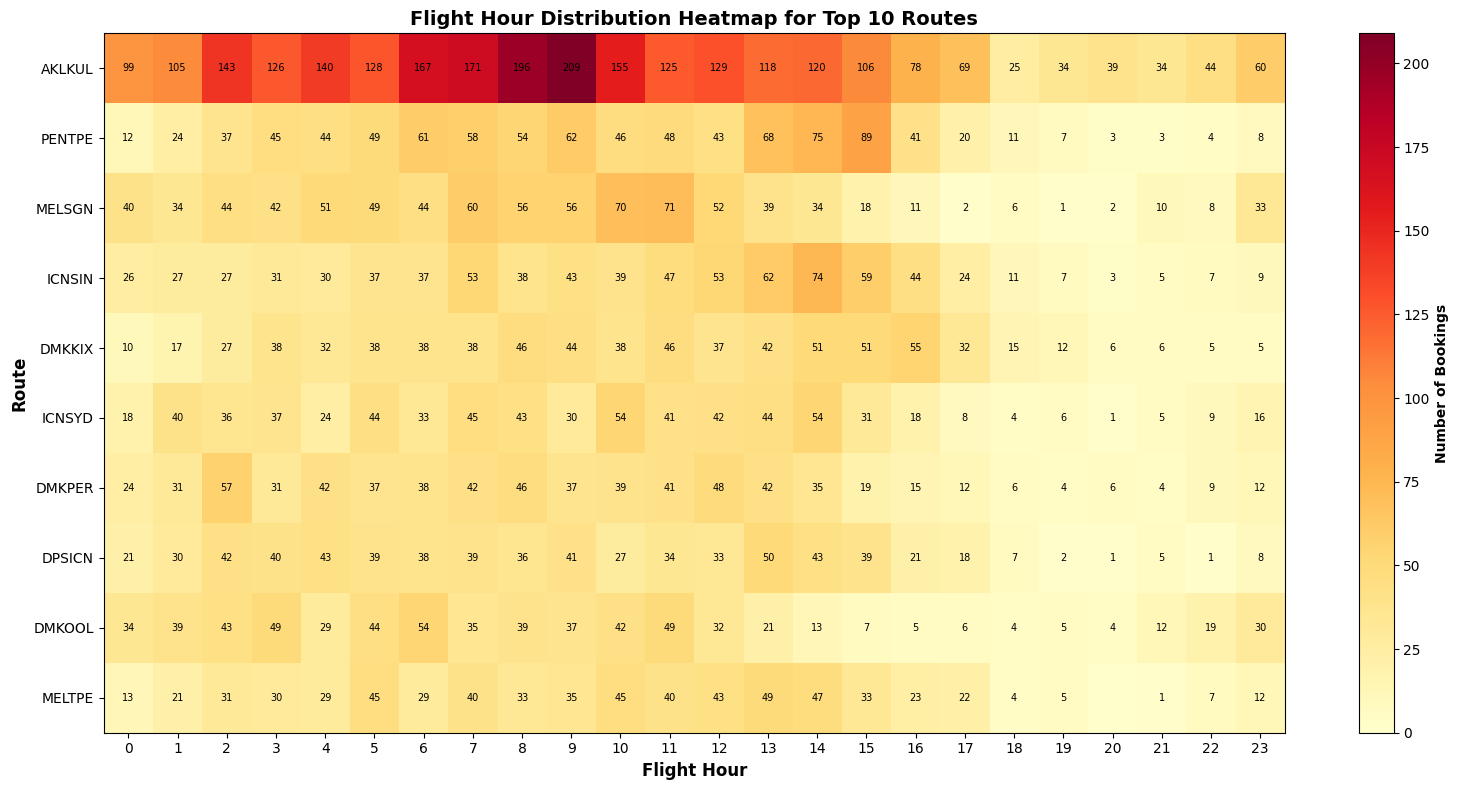

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 10 routes and create heatmap data
top_10_routes = eqdf2['route'].value_counts().head(10).index.tolist()
heatmap_data = []
for route in top_10_routes:
    route_data = eqdf2[eqdf2['route'] == route]
    hour_counts = route_data['flight_hour'].value_counts().reindex(range(24), fill_value=0)
    heatmap_data.append(hour_counts.values)

heatmap_array = np.array(heatmap_data)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto')

# Set labels and title
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_routes)
ax.set_xlabel('Flight Hour', fontweight='bold', fontsize=12)
ax.set_ylabel('Route', fontweight='bold', fontsize=12)
ax.set_title('Flight Hour Distribution Heatmap for Top 10 Routes', fontweight='bold', fontsize=14)

# Add colorbar and annotations
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Bookings', fontweight='bold')

for i in range(len(top_10_routes)):
    for j in range(24):
        if heatmap_array[i, j] > 0:
            ax.text(j, i, int(heatmap_array[i, j]), ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.show()

# **Traveler type and Class combination with highest and lowest ratings**

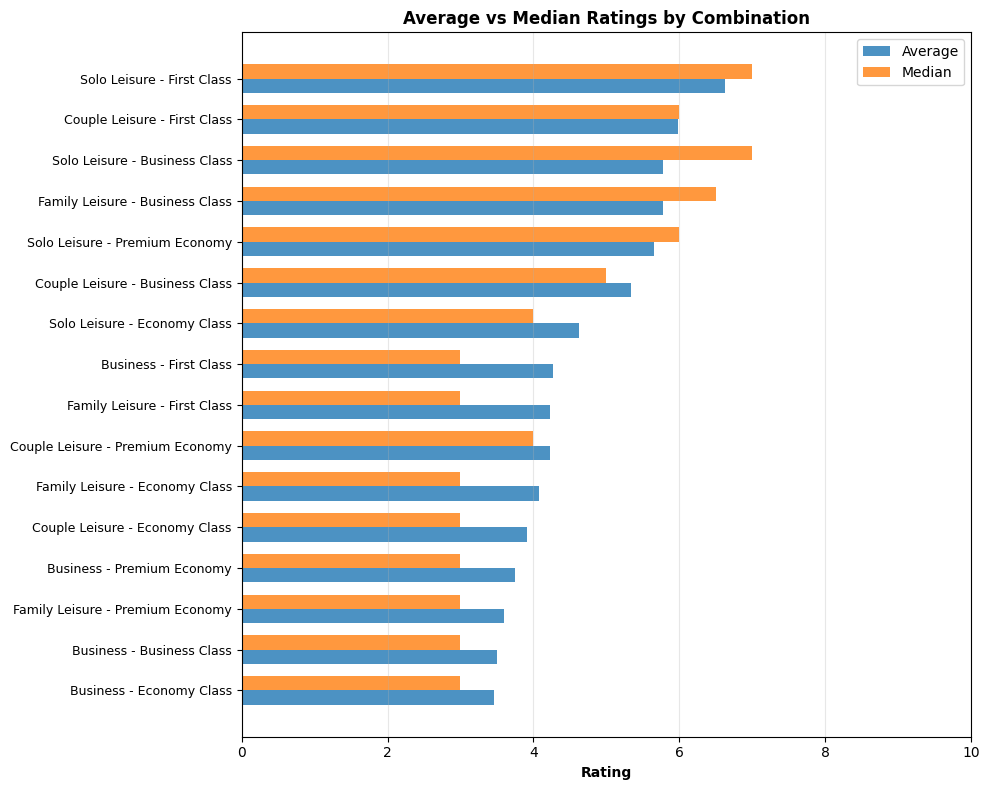

/tmp/ipython-input-4284382861.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eqdf, y='Combination', x='Rating', order=combination_order, ax=ax2, palette='RdYlGn')


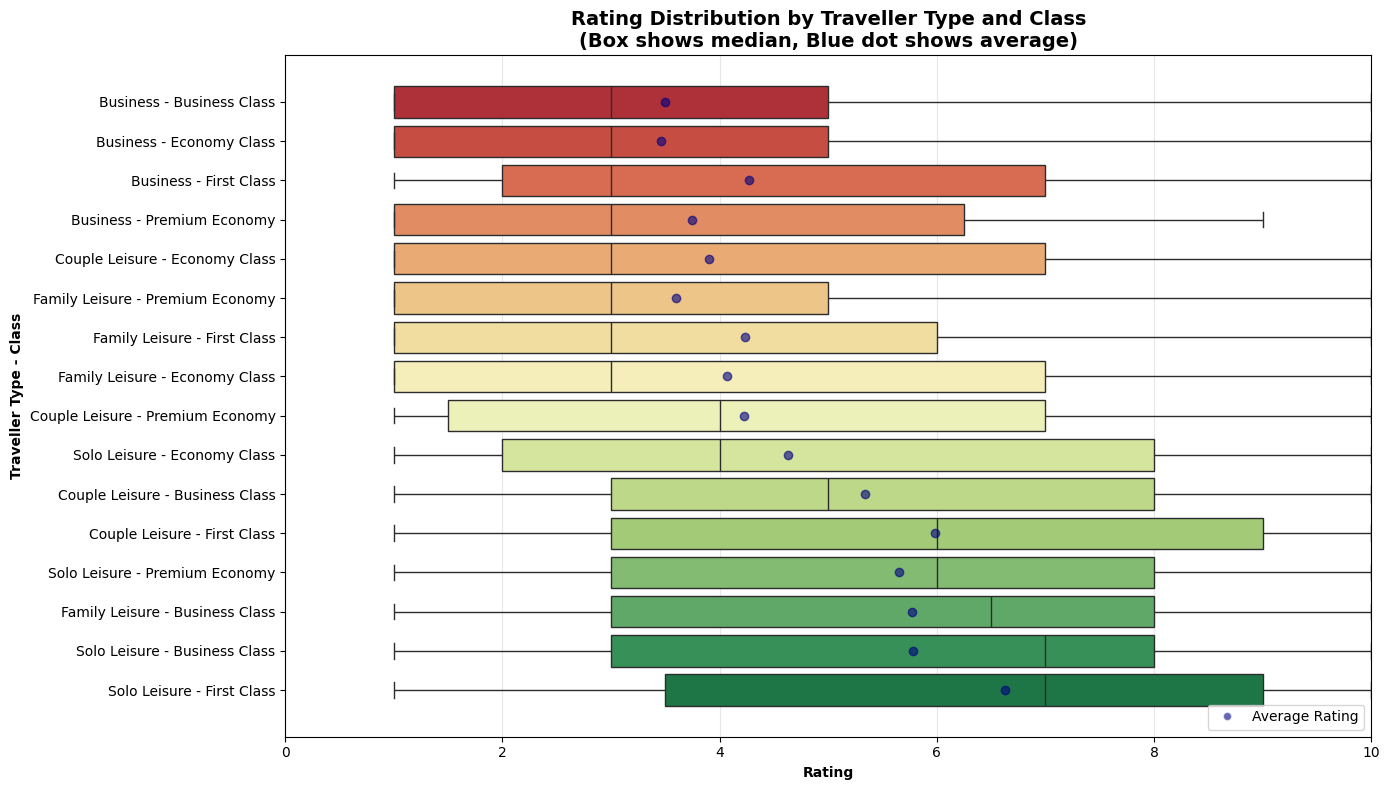

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate statistics
rating_stats = eqdf.groupby(['Traveller_Type', 'Class'])['Rating'].agg(['mean', 'median']).reset_index()
rating_stats.columns = ['Traveller_Type', 'Class', 'Average_Rating', 'Median_Rating']
rating_stats['Combination'] = rating_stats['Traveller_Type'] + ' - ' + rating_stats['Class']
rating_stats_sorted = rating_stats.sort_values('Average_Rating', ascending=True)

# Bar chart: Average vs Median
fig1, ax1 = plt.subplots(figsize=(10, 8))
x = np.arange(len(rating_stats_sorted))
width = 0.35
ax1.barh(x - width/2, rating_stats_sorted['Average_Rating'], width, label='Average', alpha=0.8)
ax1.barh(x + width/2, rating_stats_sorted['Median_Rating'], width, label='Median', alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels(rating_stats_sorted['Combination'], fontsize=9)
ax1.set_xlabel('Rating', fontweight='bold')
ax1.set_title('Average vs Median Ratings by Combination', fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, 10)
plt.tight_layout()
plt.show()

# Boxplot with average markers
fig2, ax2 = plt.subplots(figsize=(14, 8))
eqdf['Combination'] = eqdf['Traveller_Type'] + ' - ' + eqdf['Class']
combination_order = eqdf.groupby('Combination')['Rating'].median().sort_values().index

sns.boxplot(data=eqdf, y='Combination', x='Rating', order=combination_order, ax=ax2, palette='RdYlGn')

# Add average markers
for i, combo in enumerate(combination_order):
    avg_rating = eqdf[eqdf['Combination'] == combo]['Rating'].mean()
    ax2.plot(avg_rating, i, marker='o', color='navy', markersize=6, alpha=0.6, zorder=3)

from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='navy',
                           markersize=6, alpha=0.6, label='Average Rating')], loc='lower right')
ax2.set_title('Rating Distribution by Traveller Type and Class\n(Box shows median, Blue dot shows average)',
              fontweight='bold', fontsize=14)
ax2.set_xlabel('Rating', fontweight='bold')
ax2.set_ylabel('Traveller Type - Class', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, 10)
plt.tight_layout()
plt.show()

First Class and Business Class Solo Leisure have the highest median rating at 7.0 meaning they yielded the best results.

---

Economy Class and Business Class Business have the lowest median rating at 3.0 meaning they yielded the worst results.